In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [4]:
def cube_surface_points(n_per_face=12):
    lin = np.linspace(-1, 1, n_per_face)
    grid = np.array(np.meshgrid(lin, lin)).T.reshape(-1, 2)
    points = []

    for x,y in grid:
        points.extend([
            [1, x, y],  [-1, x, y],  # ±X-Flächen
            [x, 1, y],  [x, -1, y],  # ±Y-Flächen
            [x, y, 1],  [x, y, -1],  # ±Z-Flächen
        ])

    return np.array(points)

In [16]:
n = 100
sps = np.sqrt(n / 6)
print(sps)
print(np.ceil(sps))
cube_points = cube_surface_points(int(np.ceil(sps)))
print(cube_points.shape)

# noramlize
cube_points = cube_points / np.linalg.norm(cube_points, axis=1, keepdims=True)

4.08248290463863
5.0
(150, 3)


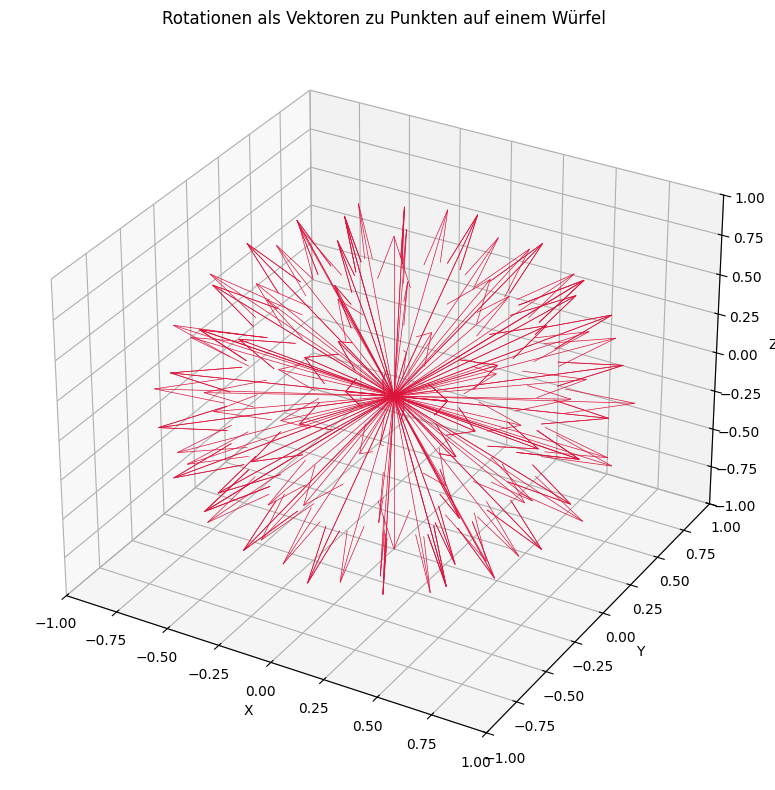

In [17]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

ax.quiver(
    np.zeros(len(cube_points)),
    np.zeros(len(cube_points)),
    np.zeros(len(cube_points)),
    cube_points[:, 0],
    cube_points[:, 1],
    cube_points[:, 2],
    length=1.0,
    normalize=False,
    color='crimson',
    linewidth=0.5
)

ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
ax.set_zlim([-1, 1])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Rotationen als Vektoren zu Punkten auf einem Würfel')

plt.tight_layout()
plt.show()

In [31]:
for x,y,z in cube_points:
    theta = np.arcsin(z)
    phi = np.arctan2(y, x)
    if abs(x - np.cos(phi) * np.cos(theta)) > 0.0000001:
        print(abs(x - np.cos(phi) * np.cos(theta)) < 0.0000001)

In [ ]:
import 